# Sioux Falls Logit-Based Stochastic User Equilibrium

This notebook implements a small research-style project using the Sioux Falls traffic network.

**Research question**

> How stable is a logit-based stochastic user-equilibrium traffic assignment under changes in route-choice sensitivity, route set size, and OD-demand perturbations?

The notebook covers:

1. Load Sioux Falls network, node, and OD data.
2. Build a directed graph.
3. Generate top-\(K\) candidate paths for every OD pair.
4. Implement link costs, logit route choice, and Method of Successive Averages (MSA).
5. Visualize convergence, equilibrium flows, route-set sensitivity, \(\theta\)-sensitivity, and demand-perturbation sensitivity.



In [3]:
# Core imports
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Matplotlib default styling is used intentionally.
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


## 1. Load data


Expected files:

- `SiouxFalls_net.csv`
- `SiouxFalls_node.csv`
- `SiouxFalls_od.csv`


In [5]:
# Change this if your CSV files are stored elsewhere.
candidate_dirs = [Path("."), Path("/mnt/data")]

filenames = {
    "net": "SiouxFalls_net.csv",
    "node": "SiouxFalls_node.csv",
    "od": "SiouxFalls_od.csv",
}

DATA_DIR = None
for d in candidate_dirs:
    if all((d / f).exists() for f in filenames.values()):
        DATA_DIR = d
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find all Sioux Falls CSV files. "
        "Put them in the same folder as this notebook or set DATA_DIR manually."
    )

net = pd.read_csv(DATA_DIR / filenames["net"])
nodes = pd.read_csv(DATA_DIR / filenames["node"])
od = pd.read_csv(DATA_DIR / filenames["od"])

print(f"Loaded data from: {DATA_DIR.resolve()}")
print(f"Nodes: {len(nodes)}")
print(f"Directed links: {len(net)}")
print(f"OD pairs: {len(od)}")
print(f"Total OD demand: {od['Ton'].sum():,.0f}")

display(net.head())
display(nodes.head())
display(od.head())


Loaded data from: /Users/yujiewu/Desktop/ESDA dissertation/traffic
Nodes: 24
Directed links: 76
OD pairs: 528
Total OD demand: 360,600


,LINK,A,B,a0,a1,a2,a3,a4
0,0,1,2,6,0,0,0,2.000000e-18
1,1,1,3,4,0,0,0,2.000000e-18
2,2,2,1,6,0,0,0,2.000000e-18
3,3,2,6,5,0,0,0,1.241000e-15
4,4,3,1,4,0,0,0,2.000000e-18


,Node,X,Y
0,1,50000,510000
1,2,320000,510000
2,3,50000,440000
3,4,130000,440000
4,5,220000,440000


,O,D,Ton
0,1,2,100
1,1,3,100
2,1,4,500
3,1,5,200
4,1,6,300


## 2. Mathematical formulation

Let \(G=(N,A)\) be a directed transport network.

For each link \(a\), link flow is \(x_a\). The data provides polynomial link-cost coefficients:

\[
t_a(x_a)=a_{0,a}+a_{1,a}x_a+a_{2,a}x_a^2+a_{3,a}x_a^3+a_{4,a}x_a^4.
\]

For an OD pair \(w=(o,d)\), demand is \(q_w\). Given a candidate path set \(R_w\), path cost is

\[
C_r(x)=\sum_{a\in A}\delta_{ar}t_a(x_a).
\]

The logit path-choice probability is

\[
P_r(x)=\frac{\exp(-\theta C_r(x))}{\sum_{s\in R_w}\exp(-\theta C_s(x))}.
\]

Path flow is

\[
f_r=q_wP_r(x).
\]

The induced link flow is

\[
F_a(x)=\sum_w\sum_{r\in R_w}\delta_{ar}f_r.
\]

The stochastic user equilibrium is a fixed-point problem:

\[
x=F(x).
\]

We solve it with Method of Successive Averages:

\[
x^{(k+1)}=(1-\lambda_k)x^{(k)}+\lambda_kF(x^{(k)}),
\qquad
\lambda_k=\frac{1}{k+1}.
\]


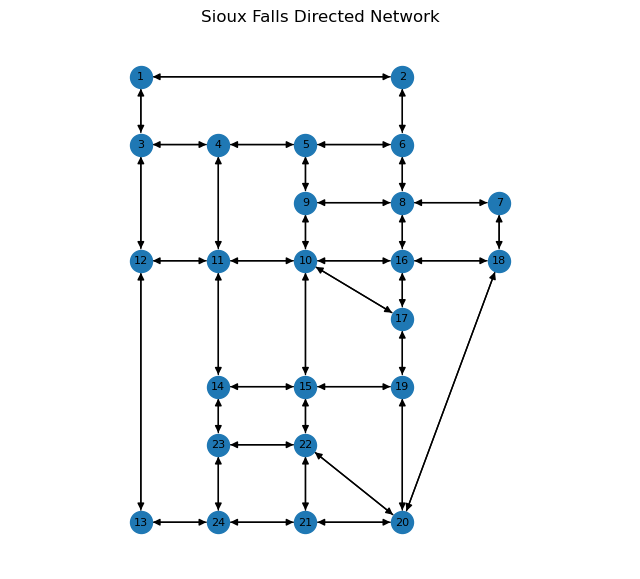

In [6]:
# Build directed graph using free-flow cost a0 as initial path-generation weight.
G = nx.DiGraph()

for _, row in net.iterrows():
    G.add_edge(
        int(row["A"]),
        int(row["B"]),
        weight=float(row["a0"]),
        link_id=int(row["LINK"]),
    )

# Node positions for plotting.
pos = {
    int(row["Node"]): (float(row["X"]), float(row["Y"]))
    for _, row in nodes.iterrows()
}

# Basic network visualization.
plt.figure(figsize=(8, 7))
nx.draw_networkx_nodes(G, pos, node_size=250)
nx.draw_networkx_labels(G, pos, font_size=8)
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=10, width=1)
plt.title("Sioux Falls Directed Network")
plt.axis("equal")
plt.axis("off")
plt.show()


## 3. Candidate path generation

The full set of feasible paths for each OD pair can be very large. To make the logit denominator computationally feasible, we approximate each OD's route-choice set with the top-\(K\) shortest simple paths under free-flow cost.

This is an approximation:

\[
\widetilde{R}_w=\{r_1,\dots,r_K\}\subset R_w.
\]

Later we test whether results are sensitive to \(K\).


In [7]:
def generate_candidate_paths(G, od_df, K=5, weight="weight"):
    """
    Generate up to K shortest simple paths for every OD pair.

    Returns
    -------
    paths : list[dict]
        One dict per candidate path.
    od_slices : list[dict]
        Start/end path indices and demand for each OD pair.
    """
    paths = []
    od_slices = []
    start = 0

    for od_idx, row in od_df.reset_index(drop=True).iterrows():
        origin = int(row["O"])
        dest = int(row["D"])
        demand = float(row["Ton"])

        count = 0
        try:
            path_iter = nx.shortest_simple_paths(G, origin, dest, weight=weight)
            for node_path in path_iter:
                link_ids = [
                    G[u][v]["link_id"]
                    for u, v in zip(node_path[:-1], node_path[1:])
                ]
                paths.append(
                    {
                        "od_idx": od_idx,
                        "origin": origin,
                        "dest": dest,
                        "demand": demand,
                        "nodes": node_path,
                        "links": link_ids,
                        "n_links": len(link_ids),
                    }
                )
                count += 1
                if count >= K:
                    break
        except nx.NetworkXNoPath:
            count = 0

        od_slices.append(
            {
                "od_idx": od_idx,
                "origin": origin,
                "dest": dest,
                "demand": demand,
                "start": start,
                "end": start + count,
                "n_paths": count,
            }
        )
        start += count

    return paths, od_slices


def build_path_link_incidence(paths, n_links):
    """Dense path-link incidence matrix."""
    incidence = np.zeros((len(paths), n_links), dtype=float)
    for i, path in enumerate(paths):
        incidence[i, path["links"]] = 1.0
    return incidence


K_BASELINE = 5
paths, od_slices = generate_candidate_paths(G, od, K=K_BASELINE)
incidence = build_path_link_incidence(paths, n_links=len(net))

print(f"K = {K_BASELINE}")
print(f"Candidate paths generated: {len(paths):,}")
print(f"Path-link incidence matrix shape: {incidence.shape}")

path_summary = pd.DataFrame(paths)
display(path_summary[["od_idx", "origin", "dest", "demand", "nodes", "links", "n_links"]].head(10))

od_path_counts = pd.DataFrame(od_slices)["n_paths"]
print(od_path_counts.describe())


K = 5
Candidate paths generated: 2,640
Path-link incidence matrix shape: (2640, 76)


,od_idx,origin,dest,demand,nodes,links,n_links
0,0,1,2,100.0,"[1, 2]",[0],1
1,0,1,2,100.0,"[1, 3, 4, 5, 6, 2]","[1, 5, 8, 11, 13]",5
2,0,1,2,100.0,"[1, 3, 12, 11, 4, 5, 6, 2]","[1, 6, 35, 30, 8, 11, 13]",7
3,0,1,2,100.0,"[1, 3, 4, 5, 9, 8, 6, 2]","[1, 5, 8, 12, 23, 18, 13]",7
4,0,1,2,100.0,"[1, 3, 4, 5, 9, 10, 16, 8, 6, 2]","[1, 5, 8, 12, 24, 28, 46, 18, 13]",9
5,1,1,3,100.0,"[1, 3]",[1],1
6,1,1,3,100.0,"[1, 2, 6, 5, 4, 3]","[0, 3, 14, 10, 7]",5
7,1,1,3,100.0,"[1, 2, 6, 5, 4, 11, 12, 3]","[0, 3, 14, 10, 9, 32, 34]",7
8,1,1,3,100.0,"[1, 2, 6, 8, 9, 5, 4, 3]","[0, 3, 15, 20, 22, 10, 7]",7
9,1,1,3,100.0,"[1, 2, 6, 8, 16, 10, 9, 5, 4, 3]","[0, 3, 15, 21, 47, 25, 22, 10, 7]",9


count    528.0
mean       5.0
std        0.0
min        5.0
25%        5.0
50%        5.0
75%        5.0
max        5.0
Name: n_paths, dtype: float64


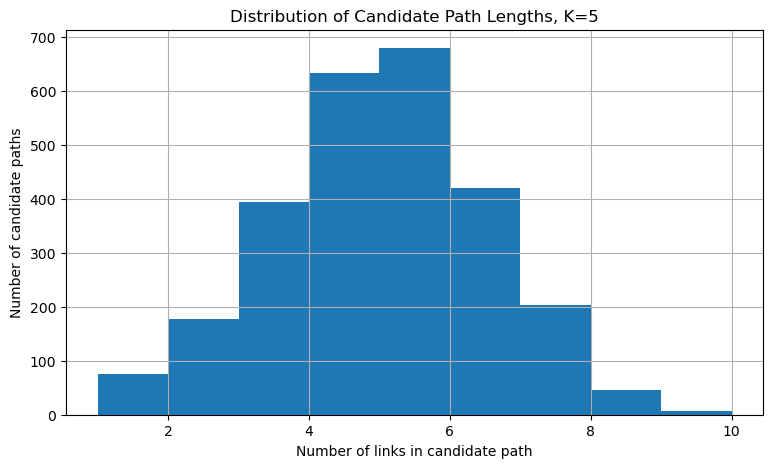

In [8]:
# Distribution of candidate path lengths.
plt.figure()
plt.hist(path_summary["n_links"], bins=range(1, int(path_summary["n_links"].max()) + 2))
plt.xlabel("Number of links in candidate path")
plt.ylabel("Number of candidate paths")
plt.title(f"Distribution of Candidate Path Lengths, K={K_BASELINE}")
plt.show()


## 4. Logit-SUE solver with MSA

In [9]:
coeff_cols = ["a0", "a1", "a2", "a3", "a4"]
coeff = net[coeff_cols].to_numpy(dtype=float)

def link_cost(flow, coeff_matrix=None):
    """Polynomial link cost t_a(x_a)."""
    if coeff_matrix is None:
        coeff_matrix = coeff
    flow = np.asarray(flow, dtype=float)
    return (
        coeff_matrix[:, 0]
        + coeff_matrix[:, 1] * flow
        + coeff_matrix[:, 2] * flow**2
        + coeff_matrix[:, 3] * flow**3
        + coeff_matrix[:, 4] * flow**4
    )


def total_system_travel_cost(flow, coeff_matrix=None):
    """T(x) = sum_a x_a t_a(x_a)."""
    return float(np.dot(flow, link_cost(flow, coeff_matrix=coeff_matrix)))


def assign_flows_given_current_flow(current_link_flow, theta, incidence, od_slices, coeff_matrix=None):
    """Compute y = F(x), plus path flows and path costs, for a fixed current link flow x."""
    current_link_cost = link_cost(current_link_flow, coeff_matrix=coeff_matrix)
    path_cost = incidence @ current_link_cost

    n_paths = incidence.shape[0]
    path_flow = np.zeros(n_paths, dtype=float)

    for item in od_slices:
        start, end = item["start"], item["end"]
        demand = item["demand"]

        if end <= start or demand <= 0:
            continue

        utilities = -theta * path_cost[start:end]

        # Stable softmax.
        utilities = utilities - np.max(utilities)
        weights = np.exp(utilities)
        probabilities = weights / np.sum(weights)

        path_flow[start:end] = demand * probabilities

    induced_link_flow = path_flow @ incidence
    return induced_link_flow, path_flow, path_cost


def solve_logit_sue(
    theta=0.05,
    K=5,
    max_iter=120,
    tol=1e-4,
    od_df=od,
    coeff_matrix=None,
    verbose=False,
):
    """Solve logit-based SUE using top-K paths and MSA."""
    paths_k, od_slices_k = generate_candidate_paths(G, od_df, K=K)
    incidence_k = build_path_link_incidence(paths_k, n_links=len(net))

    x = np.zeros(len(net), dtype=float)
    history = []

    for k in range(max_iter):
        y, path_flow, path_cost = assign_flows_given_current_flow(
            x, theta, incidence_k, od_slices_k, coeff_matrix=coeff_matrix
        )

        step_size = 1.0 / (k + 1.0)
        x_new = (1.0 - step_size) * x + step_size * y

        rel_step = np.linalg.norm(x_new - x) / (np.linalg.norm(x) + 1e-12)
        rel_fixed_point_residual = np.linalg.norm(y - x_new) / (np.linalg.norm(x_new) + 1e-12)

        history.append(
            {
                "iter": k + 1,
                "step_size": step_size,
                "rel_step": rel_step,
                "rel_fixed_point_residual": rel_fixed_point_residual,
                "total_travel_cost": total_system_travel_cost(x_new, coeff_matrix=coeff_matrix),
                "mean_link_cost": float(np.mean(link_cost(x_new, coeff_matrix=coeff_matrix))),
                "max_link_flow": float(np.max(x_new)),
            }
        )

        x = x_new

        if verbose and (k + 1) % 50 == 0:
            print(f"iter={k+1:4d}, rel_step={rel_step:.3e}, residual={rel_fixed_point_residual:.3e}")

        if (k + 1) >= 25 and rel_step < tol:
            break

    results = {
        "theta": theta,
        "K": K,
        "link_flow": x,
        "path_flow": path_flow,
        "path_cost": path_cost,
        "paths": paths_k,
        "od_slices": od_slices_k,
        "incidence": incidence_k,
        "history": pd.DataFrame(history),
        "coeff_matrix": coeff if coeff_matrix is None else coeff_matrix,
    }
    return results


## 5. Baseline equilibrium

In [38]:
THETA_BASELINE = 0.05

baseline = solve_logit_sue(
    theta=THETA_BASELINE,
    K=K_BASELINE,
    max_iter=120,
    tol=1e-4,
    verbose=True,
)

hist = baseline["history"]
x_star = baseline["link_flow"]

print(f"Baseline theta: {THETA_BASELINE}")
print(f"Baseline K: {K_BASELINE}")
print(f"Iterations: {len(hist)}")
print(f"Final relative step: {hist['rel_step'].iloc[-1]:.3e}")
print(f"Final fixed-point residual: {hist['rel_fixed_point_residual'].iloc[-1]:.3e}")
print(f"Total system travel cost: {total_system_travel_cost(x_star):,.2f}")

display(hist.tail())


Baseline theta: 0.05
Baseline K: 5
Iterations: 32
Final relative step: 9.792e-05
Final fixed-point residual: 3.036e-03
Total system travel cost: 15,882,518.64


,iter,step_size,rel_step,rel_fixed_point_residual,total_travel_cost,mean_link_cost,max_link_flow
27,28,0.035714,0.000136,0.003669,1.590141e+07,15.761761,25460.757545
28,29,0.034483,0.000125,0.003490,1.589604e+07,15.757997,25455.702079
29,30,0.033333,0.000115,0.003326,1.589114e+07,15.754562,25451.047275
30,31,0.032258,0.000106,0.003175,1.588665e+07,15.751418,25446.749613
31,32,0.031250,0.000098,0.003036,1.588252e+07,15.748530,25442.771500


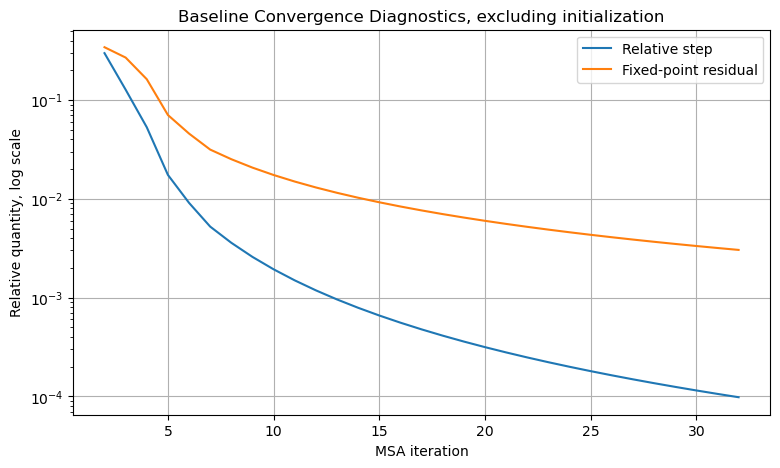

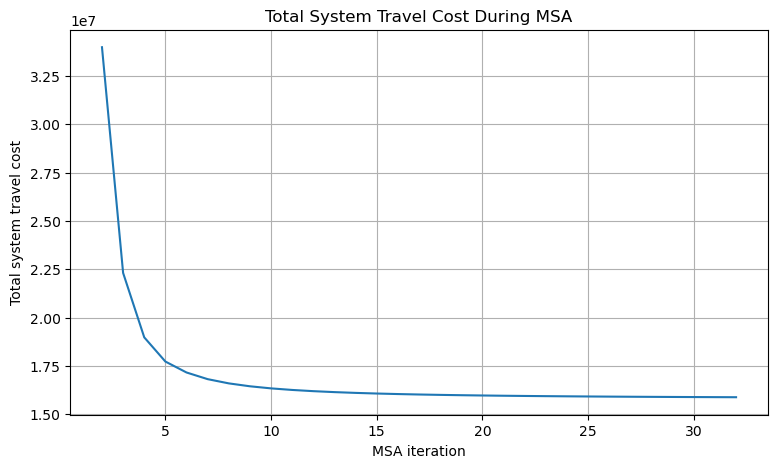

In [39]:
hist = baseline["history"]

plt.figure(figsize=(9, 5))
plt.plot(hist["iter"][1:], hist["rel_step"][1:], label="Relative step")
plt.plot(hist["iter"][1:], hist["rel_fixed_point_residual"][1:], label="Fixed-point residual")
plt.yscale("log")
plt.xlabel("MSA iteration")
plt.ylabel("Relative quantity, log scale")
plt.title("Baseline Convergence Diagnostics, excluding initialization")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(hist["iter"][1:], hist["total_travel_cost"][1:])
plt.xlabel("MSA iteration")
plt.ylabel("Total system travel cost")
plt.title("Total System Travel Cost During MSA")
plt.show()


,LINK,A,B,equilibrium_flow,equilibrium_cost,flow_x_cost
25,25,10,9,25442.771500,8.028505,204267.426989
24,24,9,10,25335.833285,7.944496,201280.422284
42,42,15,10,24793.192073,16.202193,401704.087961
27,27,10,15,24706.700376,16.060574,396803.788535
54,54,18,16,23269.534878,3.879573,90275.867508
49,49,16,18,23189.434707,3.867525,89685.713994
66,66,22,15,22224.933949,15.931169,354069.177291
45,45,15,22,22191.187459,15.852809,351792.646019
59,59,20,18,21593.834173,4.434860,95765.622387
55,55,18,20,21422.658989,4.421234,94714.589877


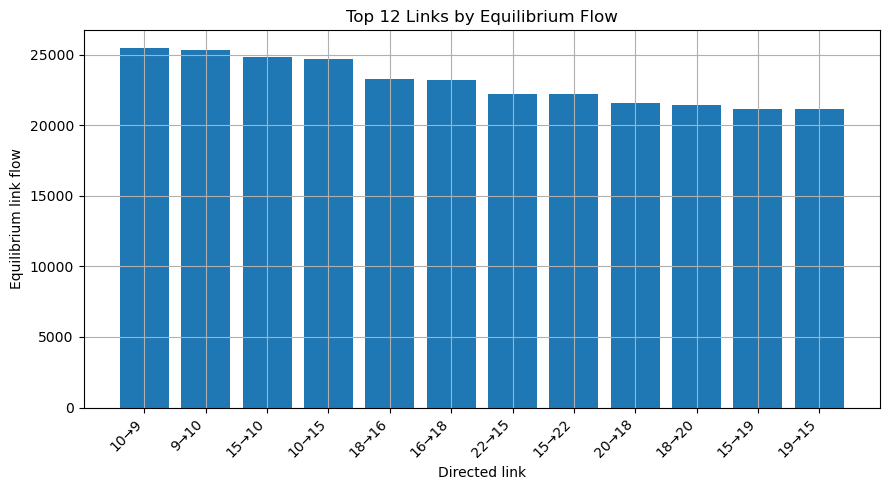

In [26]:
# Summarize equilibrium link flows.
link_results = net.copy()
link_results["equilibrium_flow"] = x_star
link_results["equilibrium_cost"] = link_cost(x_star)
link_results["flow_x_cost"] = link_results["equilibrium_flow"] * link_results["equilibrium_cost"]

top_links = link_results.sort_values("equilibrium_flow", ascending=False).head(12)
display(top_links[["LINK", "A", "B", "equilibrium_flow", "equilibrium_cost", "flow_x_cost"]])

plt.figure()
plt.bar(
    [f"{int(a)}→{int(b)}" for a, b in zip(top_links["A"], top_links["B"])],
    top_links["equilibrium_flow"],
)
plt.xlabel("Directed link")
plt.ylabel("Equilibrium link flow")
plt.title("Top 12 Links by Equilibrium Flow")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


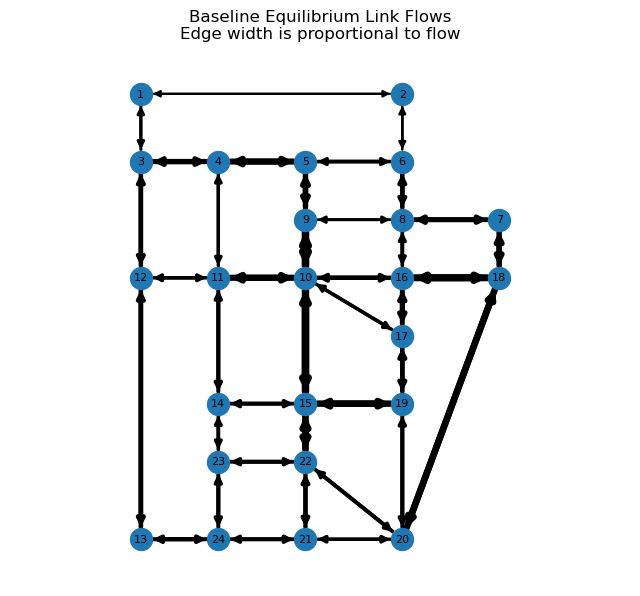

In [27]:
# Plot network with edge width scaled by equilibrium flow.
flow = link_results["equilibrium_flow"].to_numpy()
widths = 0.5 + 5.0 * flow / (flow.max() + 1e-12)

edge_width_map = {
    (int(row["A"]), int(row["B"])): widths[i]
    for i, row in net.iterrows()
}
edge_widths = [edge_width_map[e] for e in G.edges()]

plt.figure(figsize=(8, 7))
nx.draw_networkx_nodes(G, pos, node_size=250)
nx.draw_networkx_labels(G, pos, font_size=8)
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=10, width=edge_widths)
plt.title("Baseline Equilibrium Link Flows\nEdge width is proportional to flow")
plt.axis("equal")
plt.axis("off")
plt.show()


## 6. Sensitivity to route-choice parameter \(\theta\)

\(\theta\) controls how strongly users respond to cost differences.

- Small \(\theta\): choices are more random and route flows are more dispersed.
- Large \(\theta\): choices concentrate more strongly on low-cost paths.

We quantify flow concentration with a Herfindahl-style index:

\[
H=\sum_a \left(\frac{x_a}{\sum_b x_b}\right)^2.
\]


In [28]:
def flow_concentration_index(link_flow):
    share = link_flow / (np.sum(link_flow) + 1e-12)
    return float(np.sum(share**2))

theta_values = [0.01, 0.025, 0.05, 0.1]
theta_runs = []

for theta in theta_values:
    res = solve_logit_sue(theta=theta, K=K_BASELINE, max_iter=120, tol=1e-4)
    flow = res["link_flow"]
    theta_runs.append(
        {
            "theta": theta,
            "iterations": len(res["history"]),
            "total_travel_cost": total_system_travel_cost(flow),
            "max_link_flow": float(np.max(flow)),
            "flow_concentration": flow_concentration_index(flow),
            "final_residual": float(res["history"]["rel_fixed_point_residual"].iloc[-1]),
        }
    )

theta_df = pd.DataFrame(theta_runs)
display(theta_df)


,theta,iterations,total_travel_cost,max_link_flow,flow_concentration,final_residual
0,0.010,25,3.895745e+07,27251.940891,0.014507,0.001945
1,0.025,28,2.328711e+07,26414.852194,0.014622,0.002480
2,0.050,32,1.588252e+07,25442.771500,0.014762,0.003036
3,0.100,41,1.129523e+07,24116.524018,0.014919,0.003806


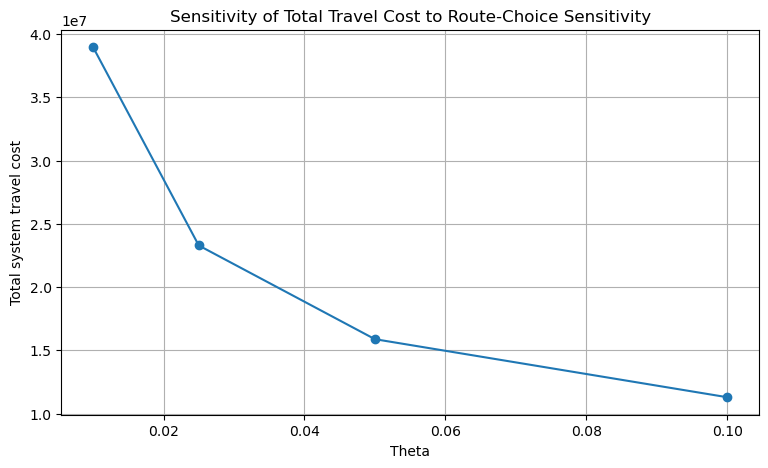

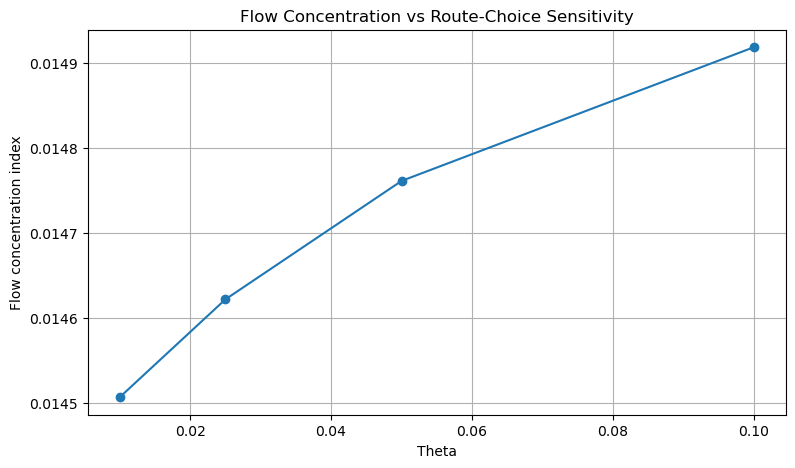

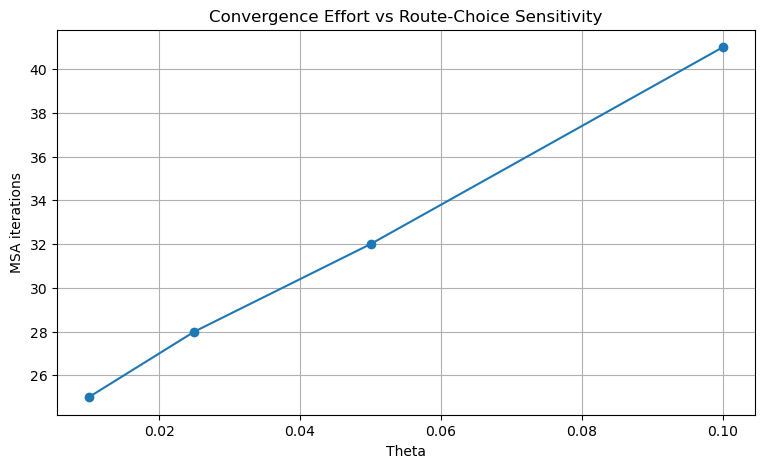

In [29]:
plt.figure()
plt.plot(theta_df["theta"], theta_df["total_travel_cost"], marker="o")
plt.xlabel("Theta")
plt.ylabel("Total system travel cost")
plt.title("Sensitivity of Total Travel Cost to Route-Choice Sensitivity")
plt.show()

plt.figure()
plt.plot(theta_df["theta"], theta_df["flow_concentration"], marker="o")
plt.xlabel("Theta")
plt.ylabel("Flow concentration index")
plt.title("Flow Concentration vs Route-Choice Sensitivity")
plt.show()

plt.figure()
plt.plot(theta_df["theta"], theta_df["iterations"], marker="o")
plt.xlabel("Theta")
plt.ylabel("MSA iterations")
plt.title("Convergence Effort vs Route-Choice Sensitivity")
plt.show()


## 7. Sensitivity to candidate route-set size \(K\)

Here we vary the number of candidate paths per OD pair:

\[
K\in\{1,3,5,10\}.
\]

This tests whether the equilibrium is robust to the route-set approximation.


In [30]:
K_values = [1, 3, 5, 8]
K_runs = []
K_flows = {}

for K in K_values:
    res = solve_logit_sue(theta=THETA_BASELINE, K=K, max_iter=120, tol=1e-4)
    flow = res["link_flow"]
    K_flows[K] = flow
    K_runs.append(
        {
            "K": K,
            "n_candidate_paths": len(res["paths"]),
            "iterations": len(res["history"]),
            "total_travel_cost": total_system_travel_cost(flow),
            "max_link_flow": float(np.max(flow)),
            "flow_concentration": flow_concentration_index(flow),
        }
    )

K_df = pd.DataFrame(K_runs)

# Compare each K to K=10 as the largest route set used here.
reference_K = max(K_values)
reference_flow = K_flows[reference_K]
K_df[f"relative_distance_to_K{reference_K}"] = [
    np.linalg.norm(K_flows[K] - reference_flow) / (np.linalg.norm(reference_flow) + 1e-12)
    for K in K_values
]

display(K_df)


,K,n_candidate_paths,iterations,total_travel_cost,max_link_flow,flow_concentration,relative_distance_to_K8
0,1,528,25,7.123654e+07,28800.000000,0.017503,0.452376
1,3,1584,31,1.393844e+07,23045.890540,0.014684,0.139885
2,5,2640,32,1.588252e+07,25442.771500,0.014762,0.064472
3,8,4224,33,1.773894e+07,26363.718218,0.014825,0.000000


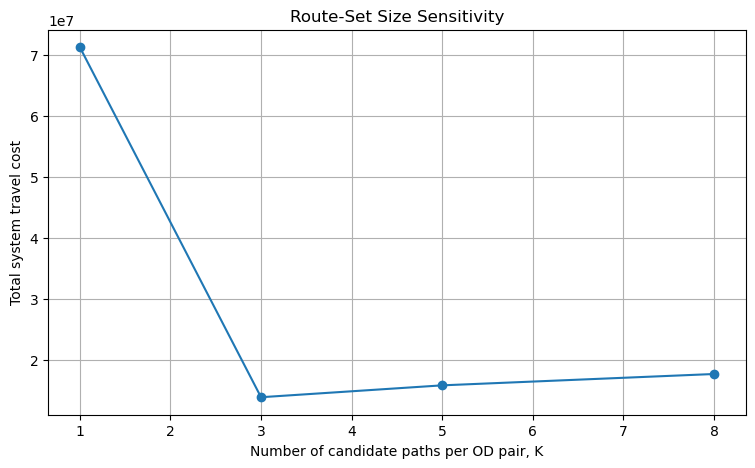

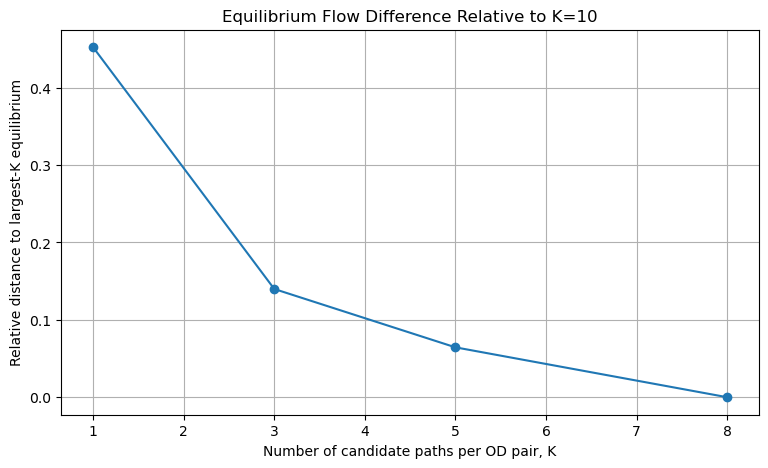

In [31]:
plt.figure()
plt.plot(K_df["K"], K_df["total_travel_cost"], marker="o")
plt.xlabel("Number of candidate paths per OD pair, K")
plt.ylabel("Total system travel cost")
plt.title("Route-Set Size Sensitivity")
plt.show()

plt.figure()
plt.plot(K_df["K"], K_df[f"relative_distance_to_K{reference_K}"], marker="o")
plt.xlabel("Number of candidate paths per OD pair, K")
plt.ylabel("Relative distance to largest-K equilibrium")
plt.title("Equilibrium Flow Difference Relative to K=10")
plt.show()


## 8. Demand perturbation experiment

Now we perturb OD demand:

\[
q'_w=q_w(1+\epsilon_w),
\qquad
\epsilon_w\sim \mathcal{N}(0,\sigma^2),
\]

clipped so that demand remains non-negative.

We then compute an empirical sensitivity ratio:

\[
S_q=
\frac{
\|x^*(q')-x^*(q)\|/\|x^*(q)\|
}{
\|q'-q\|/\|q\|
}.
\]

This is similar in spirit to an empirical condition number: it measures how much the equilibrium flow changes relative to the size of the demand perturbation.


In [32]:
def perturb_od_demand(od_df, sigma, rng):
    perturbed = od_df.copy()
    noise = rng.normal(loc=0.0, scale=sigma, size=len(perturbed))
    multiplier = np.maximum(0.0, 1.0 + noise)
    perturbed["Ton"] = perturbed["Ton"].to_numpy(dtype=float) * multiplier
    return perturbed


sigma_values = [0.01, 0.05, 0.10, 0.20]
n_replications = 4

demand_rows = []
baseline_q = od["Ton"].to_numpy(dtype=float)
baseline_flow = baseline["link_flow"]

for sigma in sigma_values:
    for rep in range(n_replications):
        od_p = perturb_od_demand(od, sigma=sigma, rng=rng)
        res_p = solve_logit_sue(
            theta=THETA_BASELINE,
            K=K_BASELINE,
            max_iter=120,
            tol=1e-4,
            od_df=od_p,
        )
        q_p = od_p["Ton"].to_numpy(dtype=float)
        flow_p = res_p["link_flow"]

        rel_q_change = np.linalg.norm(q_p - baseline_q) / (np.linalg.norm(baseline_q) + 1e-12)
        rel_flow_change = np.linalg.norm(flow_p - baseline_flow) / (np.linalg.norm(baseline_flow) + 1e-12)
        sensitivity = rel_flow_change / (rel_q_change + 1e-12)

        demand_rows.append(
            {
                "sigma": sigma,
                "replication": rep,
                "rel_q_change": rel_q_change,
                "rel_flow_change": rel_flow_change,
                "empirical_sensitivity": sensitivity,
                "total_travel_cost": total_system_travel_cost(flow_p),
            }
        )

demand_df = pd.DataFrame(demand_rows)
display(demand_df.groupby("sigma").agg(["mean", "std"])[
    ["rel_q_change", "rel_flow_change", "empirical_sensitivity", "total_travel_cost"]
])


rel_q_change           rel_flow_change           empirical_sensitivity  \
              mean       std            mean       std                  mean   
sigma                                                                          
0.01      0.009569  0.000378        0.001508  0.000237              0.158219   
0.05      0.050147  0.002685        0.007761  0.000512              0.154707   
0.10      0.105975  0.008541        0.013988  0.000671              0.132460   
0.20      0.192407  0.009367        0.028968  0.005100              0.151509   

                total_travel_cost                 
            std              mean            std  
sigma                                             
0.01   0.028496      1.586377e+07   32492.504816  
0.05   0.002539      1.595418e+07   88583.666391  
0.10   0.009254      1.587002e+07   85389.246341  
0.20   0.031389      1.599723e+07  274076.650991

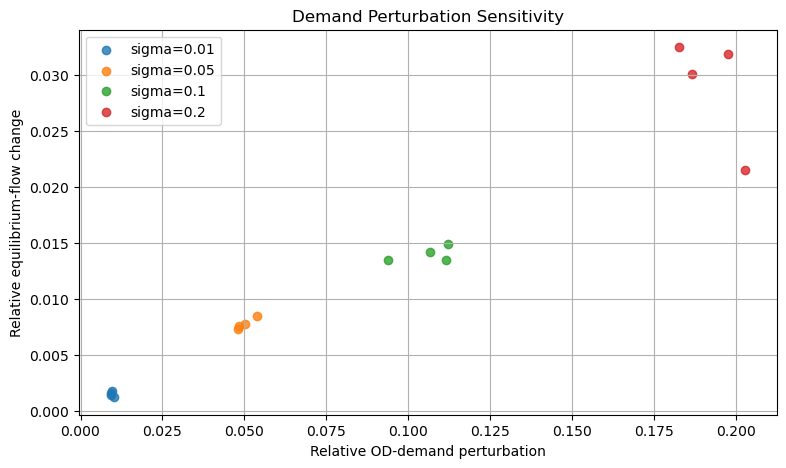

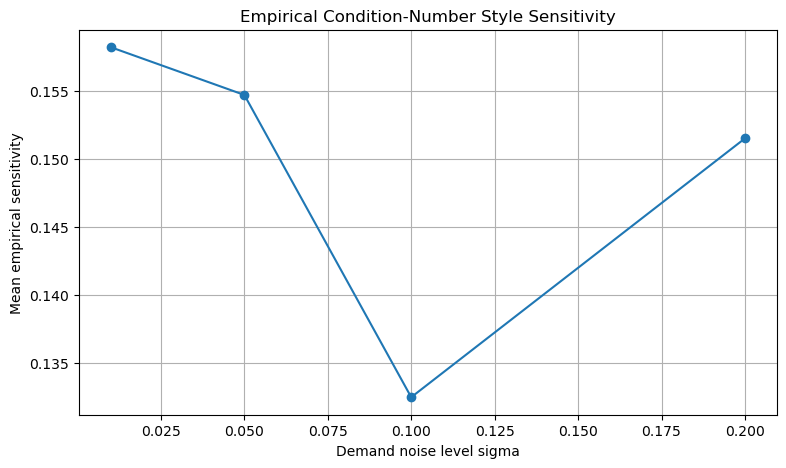

In [33]:
plt.figure()
for sigma, group in demand_df.groupby("sigma"):
    plt.scatter(
        group["rel_q_change"],
        group["rel_flow_change"],
        label=f"sigma={sigma}",
        alpha=0.8,
    )
plt.xlabel("Relative OD-demand perturbation")
plt.ylabel("Relative equilibrium-flow change")
plt.title("Demand Perturbation Sensitivity")
plt.legend()
plt.show()

summary = demand_df.groupby("sigma", as_index=False)["empirical_sensitivity"].mean()

plt.figure()
plt.plot(summary["sigma"], summary["empirical_sensitivity"], marker="o")
plt.xlabel("Demand noise level sigma")
plt.ylabel("Mean empirical sensitivity")
plt.title("Empirical Condition-Number Style Sensitivity")
plt.show()


## 9. Small adversarial-style link-cost perturbation

This experiment asks:

> Which single-link cost perturbation produces the largest increase in total system travel cost?

We multiply one link's \(a_0\) free-flow cost by \(1+\rho\), recompute equilibrium, and rank links by the change in system cost.

This is not a full adversarial optimization problem, but it is a useful first-order stress test.


In [34]:
rho = 0.10  # 10% increase in one link's free-flow cost a0.
attack_rows = []

baseline_T = total_system_travel_cost(baseline_flow)

candidate_attack_links = link_results.sort_values("equilibrium_flow", ascending=False).head(20)["LINK"].tolist()

for link_id in candidate_attack_links:
    coeff_mod = coeff.copy()
    link_idx = int(link_id)
    coeff_mod[link_idx, 0] = coeff_mod[link_idx, 0] * (1.0 + rho)

    res_attack = solve_logit_sue(
        theta=THETA_BASELINE,
        K=K_BASELINE,
        max_iter=120,
        tol=1e-4,
        coeff_matrix=coeff_mod,
    )
    flow_attack = res_attack["link_flow"]
    T_attack = total_system_travel_cost(flow_attack, coeff_matrix=coeff_mod)

    attack_rows.append(
        {
            "LINK": link_idx,
            "A": int(net.loc[link_idx, "A"]),
            "B": int(net.loc[link_idx, "B"]),
            "baseline_flow": baseline_flow[link_idx],
            "baseline_cost": link_cost(baseline_flow)[link_idx],
            "attacked_total_travel_cost": T_attack,
            "delta_total_travel_cost": T_attack - baseline_T,
            "relative_delta_total_travel_cost": (T_attack - baseline_T) / (baseline_T + 1e-12),
            "relative_flow_change": np.linalg.norm(flow_attack - baseline_flow)
            / (np.linalg.norm(baseline_flow) + 1e-12),
        }
    )

attack_df = pd.DataFrame(attack_rows)
top_attacks = attack_df.sort_values("delta_total_travel_cost", ascending=False).head(12)
display(top_attacks)


,LINK,A,B,baseline_flow,baseline_cost,attacked_total_travel_cost,delta_total_travel_cost,relative_delta_total_travel_cost,relative_flow_change
2,42,15,10,24793.192073,16.202193,1.589471e+07,12188.868625,0.000767,0.001101
3,27,10,15,24706.700376,16.060574,1.589449e+07,11967.816521,0.000754,0.001092
8,59,20,18,21593.834173,4.434860,1.589137e+07,8848.189485,0.000557,0.000837
9,55,18,20,21422.658989,4.421234,1.589123e+07,8711.205582,0.000548,0.000831
4,54,18,16,23269.534878,3.879573,1.588984e+07,7321.493940,0.000461,0.000946
18,22,9,5,17529.796860,12.082210,1.588969e+07,7171.994960,0.000452,0.000982
5,49,16,18,23189.434707,3.867525,1.588968e+07,7156.418595,0.000451,0.000940
19,12,5,9,17365.871164,11.820992,1.588966e+07,7141.305391,0.000450,0.000982
0,25,10,9,25442.771500,8.028505,1.588887e+07,6355.313861,0.000400,0.000676
1,24,9,10,25335.833285,7.944496,1.588882e+07,6306.095730,0.000397,0.000674


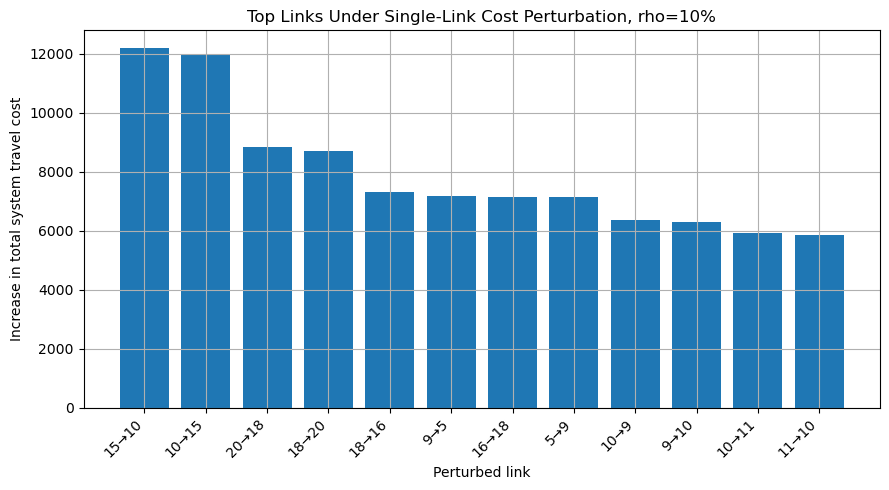

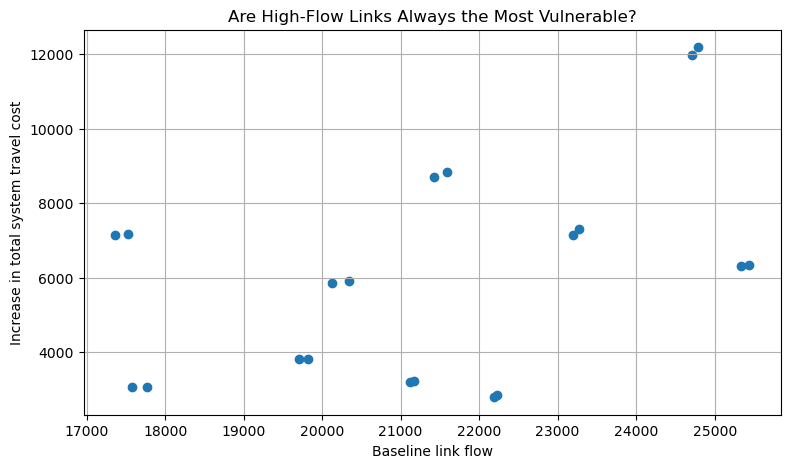

In [35]:
plt.figure()
plt.bar(
    [f"{int(a)}→{int(b)}" for a, b in zip(top_attacks["A"], top_attacks["B"])],
    top_attacks["delta_total_travel_cost"],
)
plt.xlabel("Perturbed link")
plt.ylabel("Increase in total system travel cost")
plt.title(f"Top Links Under Single-Link Cost Perturbation, rho={rho:.0%}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(attack_df["baseline_flow"], attack_df["delta_total_travel_cost"])
plt.xlabel("Baseline link flow")
plt.ylabel("Increase in total system travel cost")
plt.title("Are High-Flow Links Always the Most Vulnerable?")
plt.show()
